# Interacting with CLIP

This is a self-contained notebook that shows how to download and run CLIP models, calculate the similarity between arbitrary image and text inputs, and perform zero-shot image classifications.

# Enviroment setup

Before we begin we will go through some setup to make the enviroment ready for image classification. \
In this section we will primarily focus on:
* ```Imports```
* ```Loading data```
* ```Verifying pytorch installation```
* ```Loading model```

## Imports

In [194]:
from __future__ import annotations

import gc
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from transformers import CLIPModel, CLIPProcessor, CLIPTokenizer
import time

## Runtime measuring

Defined a function to test runtime used for testing

In [61]:
def measure_runtime(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start

## Loading data

Here we load in the dataset that we will use in this project.
```CIFAR-10```

In [195]:
from pathlib import Path
from PIL import Image

# Change this to "dataset" if your folder is named dataset/
root_dir = Path("images")

images = []
image_paths = []
labels = []

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

for class_dir in sorted(root_dir.iterdir()):
    if not class_dir.is_dir():
        continue

    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() not in valid_ext:
            continue

        with Image.open(img_path) as img:
            images.append(img.convert("RGB"))
        image_paths.append(str(img_path))
        labels.append(class_dir.name)

print(f"Loaded {len(images)} images from {len(set(labels))} classes.")
print(f"First path: {image_paths[0] if image_paths else 'No images found'}")

Loaded 10000 images from 10 classes.
First path: images\airplane\0000.jpg


## Verifying pytorch installation

This section is only for verifying the installation of `pytorch` as using `pip install pytorch` only installs the cpu version of the library and thus does not enable the usage of GPU

In [177]:
import numpy as np
import torch


print("Torch version:", torch.__version__)

if "cpu" in torch.__version__:
    print(f"This is a cpu only version of pytorch.")


print("If you have a GPU enabled pytorch version, one of the results below should be true, and correspond to what GPU you have. \nFor example CUDA if you have NVIDIA GPU")

print("CUDA available:", torch.cuda.is_available())
print("ROCm available:", torch.version.hip is not None)
print("MPS available:", torch.backends.mps.is_available())
print("XPU available:", hasattr(torch, "xpu") and torch.xpu.is_available())
print("DirectML available:", hasattr(torch, "directml") and torch.directml.is_available())

Torch version: 2.10.0+cu128
If you have a GPU enabled pytorch version, one of the results below should be true, and correspond to what GPU you have. 
For example CUDA if you have NVIDIA GPU
CUDA available: True
ROCm available: False
MPS available: False
XPU available: False
DirectML available: False


### If you have a cpu only version

If you have a cpu version only of pytorch it will be fine. The code will still run, but inference speed will be dramatically reduced.
Therefore it is recommended to install a pytorch version that can utilize your GPU.

Follow the link to find more info: https://pytorch.org/get-started/locally/ \
NB! NVIDIA is relatively easy to get started with since you then can download one of the CUDA versions

## Loading the model

Here we will load the model which we will use. \
The model which we will use for this project is ```ViT-B/32``` from openAI. The model will be loaded from huggingface, and more info about the model can be found on the huggingface site: https://huggingface.co/openai/clip-vit-base-patch32 \
Documentation for the CLIP processor: https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPProcessor \
Documentation for the CLIP model: https://huggingface.co/docs/transformers/model_doc/clip#transformers.CLIPModel

In [178]:
gc.collect()
torch.cuda.empty_cache()

"""Checks if a cuda (NVIDIA GPU) is available and falls back to CPU if not"""
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
    #torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
).to(device)
model.eval()
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
    #torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
)


context_length = model.text_model.config.max_position_embeddings
vocab_size = model.text_model.config.vocab_size



print("Device:", device)
print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)


#model = torch.compile(model, mode="max-autotune", fullgraph=True)
#processor = torch.compile(processor, mode="max-autotune", fullgraph=True)


Loading weights: 100%|████████████████████████████████████████████████████████████| 398/398 [00:00<00:00, 18143.54it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Model parameters: 151,277,313
Context length: 77
Vocab size: 49408


We have now loaded in the model, and can see that the code has printed out some info about the model. But what does ```Model parameters```, ```Context length```, and ```Vocab size``` refer to?

### Model parameters

This is how many trainable weights the model consist of and is the part of the model that takes the most storage space. \
As we can see, it has a little over 150 million parameters. This may seem like a lot, but quickly becomes small relative to other models out the which can reach into the billions.

### Context length

Context lenght can sort of be interpreted as the "prompt length". More precisely it is the maximum number of ```tokens``` the model can process for a single input. When you give in a prompt to a model, the text has to be translated into numerical values before it can be pushed through the model.


### Vocab size

This is the number of unique tokens that models tokenizer can produce. Each token is associated with a learned vector, and can encode semantics, morphology, style and so on. The model has trained associations with different tokens. Some words in a prompt may be translated into multiple tokens, whilst other words may be translated into only one token.

### Loading model in 16 bit

Given below is an example of how we can load the model in a lower precision format. \
Normally the model is loaded in 32 bit floats, but with an compatible GPU it is possible to load the model in a less precise format. This however comes at the cost of precision, but reduces memory usage, and can sometimes drastically reduce inference speed.

In [32]:
gc.collect()
torch.cuda.empty_cache()

"""Checks if a cuda (NVIDIA GPU) is available and falls back to CPU if not"""
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
).to(device)
model.eval()
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
)


context_length = model.text_model.config.max_position_embeddings
vocab_size = model.text_model.config.vocab_size



print("Device:", device)
print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 398/398 [00:00<00:00, 3552.07it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Model parameters: 151,277,313
Context length: 77
Vocab size: 49408


### How much space does the model take?

In [182]:
print(f"CUDA Memory Allocated: {torch.cuda.memory_allocated(device)/1024**2:.2f} MB")
print(f"CUDA Memory Reserved: {torch.cuda.memory_reserved(device)/1024**2:.2f} MB")


CUDA Memory Allocated: 1413.30 MB
CUDA Memory Reserved: 1528.00 MB


When we run the code we will see how much memory on the GPU is allocated. (NB! NVIDIA specific. Does not work if model on CPU) \
You can scroll up, and load in the model normally, and loading it in 16 bit, and see how this influence amount of allocated memory

# Image Preprocessing

We resize the input images and center-crop them to conform with the image resolution that the model expects. Before doing so, we will normalize the pixel intensity using the dataset mean and standard deviation.

The second return value from `clip.load()` contains a torchvision `Transform` that performs this preprocessing.



## Loading in image to use

Image loading \
Read in image from folder → Convert to RGB → add to list → process

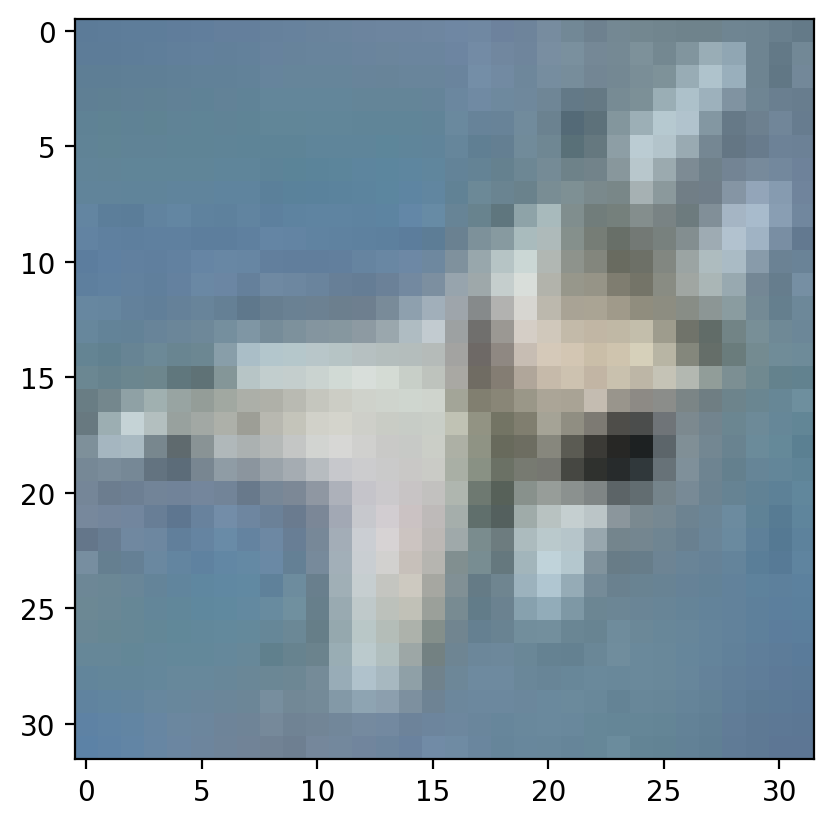

In [285]:
import os
original_images = []

# Loads in the first image of an airplane in the CIFAR-10 dataset
image = Image.open("images/airplane/0000.jpg")


# appends the read image to the original_images list
original_images.append(image)
# shows the image
plt.imshow(original_images[0])
plt.imshow(images[1])

Here we can see that we have loaded in the first airplane image of ```CIFAR-10```

## Creating embedding from image

In [286]:
# preprocess the image using CLIPProcessor
image = processor(images=original_images, return_tensors='pt')

# Print out info about the preprocessed image
print(f'Prints out tensor shape representing image: {image.data["pixel_values"].shape}')
print(f'Prints out the datatype for the tensor values: {image.data["pixel_values"].dtype} \n')

# uncomment function to look at the internal values of the tensor
#print(image.data['pixel_values'])

image_embeds = model.get_image_features(pixel_values=image["pixel_values"].to("cuda"))
print(f'Prints out the tensor shape of the image embedding: {image_embeds.pooler_output.shape}')



Prints out tensor shape representing image: torch.Size([1, 3, 224, 224])
Prints out the datatype for the tensor values: torch.float32 

Prints out the tensor shape of the image embedding: torch.Size([1, 512])


## explenation

Above we have preprocessed an image, and then created an embedding. \
Before we create the embedding we preprocess into a class called batchfeature \
Documentation for batchfeature: https://huggingface.co/docs/transformers/v5.3.0/en/main_classes/feature_extractor#transformers.BatchFeature \
The reason we get the batchfeature when we have preprocessed the image is because it is possible to preprocess images and embeddings in batches.

The shape of the preprocessed batch feature is [1, 3, 224, 224] which we can see from the output of the code above. \
The first digit represents the number of images. The number is one since we only have one image in the batch feature. \
The three last digits represent the image. The number three represents the number of color channels, which is three since we are using RGB. \
224 occur two times and is the resolution of the image. This is connected with what input resolution the model is trained for, and therefore what resolution it needs to work optimally. 

# Text Preprocessing

link to an example on the hugginface site: https://huggingface.co/docs/transformers/main_classes/output


In [198]:
# Tokenize text prompt into tokens. Max number of tokens is 77.
# Maximum number of tokens are also reffered to as context length
tokens = processor(text=["An image of an airplane"], return_tensors="pt", padding="max_length").to("cuda")
print(f'this is the tokens tensors shape: {tokens["input_ids"].shape} \n')


# runs the tokens through the CLIP model giving the text embedding
text_embeds = model.get_text_features(**tokens)
print(f'This is the tensor shape of the text embedding:  {text_embeds.pooler_output.shape}')
print(f'This is the used datatype of the text embedding:  {text_embeds.pooler_output.dtype}')

this is the tokens tensors shape: torch.Size([1, 77]) 

This is the tensor shape of the text embedding:  torch.Size([1, 512])
This is the used datatype of the text embedding:  torch.float32


## Interpreting the values

In the section above we have: 
- tokenized a promt
- created an text embedding from prompt tokens

# A little extra about tokenization

In [51]:
tokens = processor(text=["An image of an airplane"], return_tensors="pt", padding="max_length").to("cuda")
print(f'this is the tensor values: \n {tokens["input_ids"]} \n')


this is the tensor values: 
 tensor([[49406,   550,  2867,   539,   550, 16451, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]], device='cuda:0') 



Above we have tokenized the prompt ```An image of an airplane``` and printed out the output tensor \
if you count the number of values present, the number would be 77. \
This because this is the maximum amount of tokens you can send into the CLIP model. \
This is also reffered to as the ```context length```

## From tokens back to words

In [52]:
print(processor.tokenizer.convert_ids_to_tokens([16451]))

['airplane</w>']


From the output above, we can see that the value ```16451``` is associated with ```airplane``` \
But what are we seeing ```49407``` being repeated so many times? \
```49407``` represents the end of text token, and as the name implies tell when is the end of the text

In [53]:
print(processor.tokenizer.convert_ids_to_tokens([49407]))

['<|endoftext|>']


# Utilizing the embeddings

## Calculating cosine similarity

In [199]:
import os
original_images = []

# Loads in the first image of an airplane in the CIFAR-10 dataset
image = Image.open("images/airplane/0000.jpg")

# appends the read image to the original_images list
original_images.append(image)

# preprocess the image using CLIPProcessor
image = processor(images=original_images, return_tensors='pt')
image_embeds = model.get_image_features(pixel_values=image["pixel_values"].to("cuda"))


# Tokenize text prompt into tokens.
tokens = processor(text=["image of a airplane"], return_tensors="pt", padding="max_length").to("cuda")

# runs the tokens through the CLIP model giving the text embedding
text_embeds = model.get_text_features(**tokens)


text_norm = text_embeds.pooler_output / text_embeds.pooler_output.norm(dim=-1, keepdim=True)
image_norm = image_embeds.pooler_output / image_embeds.pooler_output.norm(dim=-1, keepdim=True)

similarity = torch.cosine_similarity(image_norm, text_norm)
print(similarity[0])

tensor(0.2132, device='cuda:0', grad_fn=<SelectBackward0>)


## Calculating top 5 matches

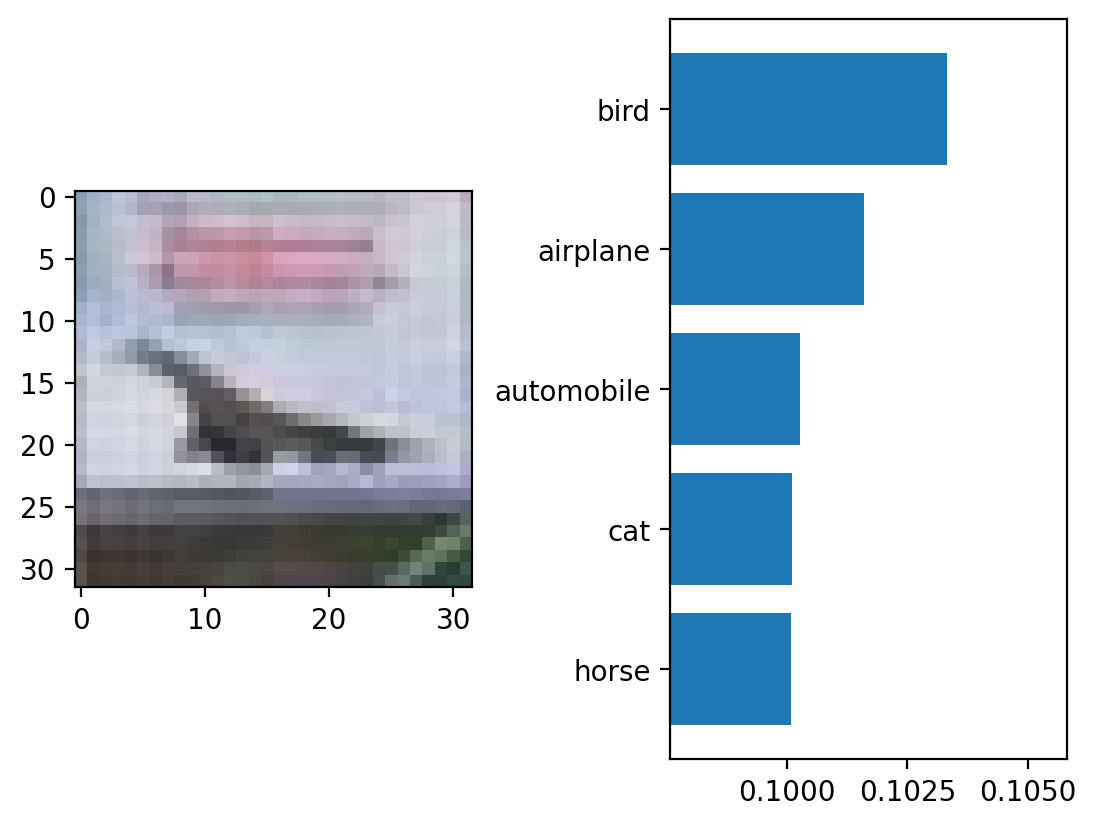

In [284]:
# Defining the class names
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]


# Turn class names into CLIP prompts
prompts = [f"a photo of a {c}" for c in class_names]


# Encode text
text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to("cuda")
text_embeds = model.get_text_features(**text_inputs)

# Encode image
image_inputs = processor(images=images[0], return_tensors="pt").to("cuda")
image_embeds = model.get_image_features(**image_inputs)


# Normalize embeddings
text_embeds = text_embeds.pooler_output / text_embeds.pooler_output.norm(dim=-1, keepdim=True)
image_embeds = image_embeds.pooler_output / image_embeds.pooler_output.norm(dim=-1, keepdim=True)

# Compute cosine similarity
similarity = torch.cosine_similarity(image_embeds, text_embeds)

# Convert to probabilities
probs = similarity.softmax(dim=0)


# Top‑5 predictions
top5 = probs.topk(5)


indices = top5.indices.detach().cpu().numpy()
probs = top5.values.detach().cpu().numpy()



labels = [class_names[i] for i in top5_indices]


labels.reverse()
probs = probs[::-1]

plt.subplot(1, 2, 1)
plt.imshow(images[0])

plt.subplot(1,2,2)
plt.barh(labels, probs)
plt.xlim(probs[0]-0.0025,probs[-1]+0.0025)

plt.subplots_adjust(wspace=0.5)
plt.show()



# Setting up input images and texts

We are going to feed 8 example images and their textual descriptions to the model, and compare the similarity between the corresponding features.

The tokenizer is case-insensitive, and we can freely give any suitable textual descriptions.

In [59]:
import os
try:
    import skimage
except ModuleNotFoundError:
    %pip install scikit-image
    import skimage
import IPython.display
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from collections import OrderedDict
import torch

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# images in skimage to use and their textual descriptions
descriptions = {
    "page": "a page of text about segmentation",
    "chelsea": "a facial photo of a tabby cat",
    "astronaut": "a portrait of an astronaut with the American flag",
    "rocket": "a rocket standing on a launchpad",
    "motorcycle_right": "a red motorcycle standing in a garage",
    "camera": "a person looking at a camera on a tripod",
    "horse": "a black-and-white silhouette of a horse",
    "coffee": "a cup of coffee on a saucer"
}

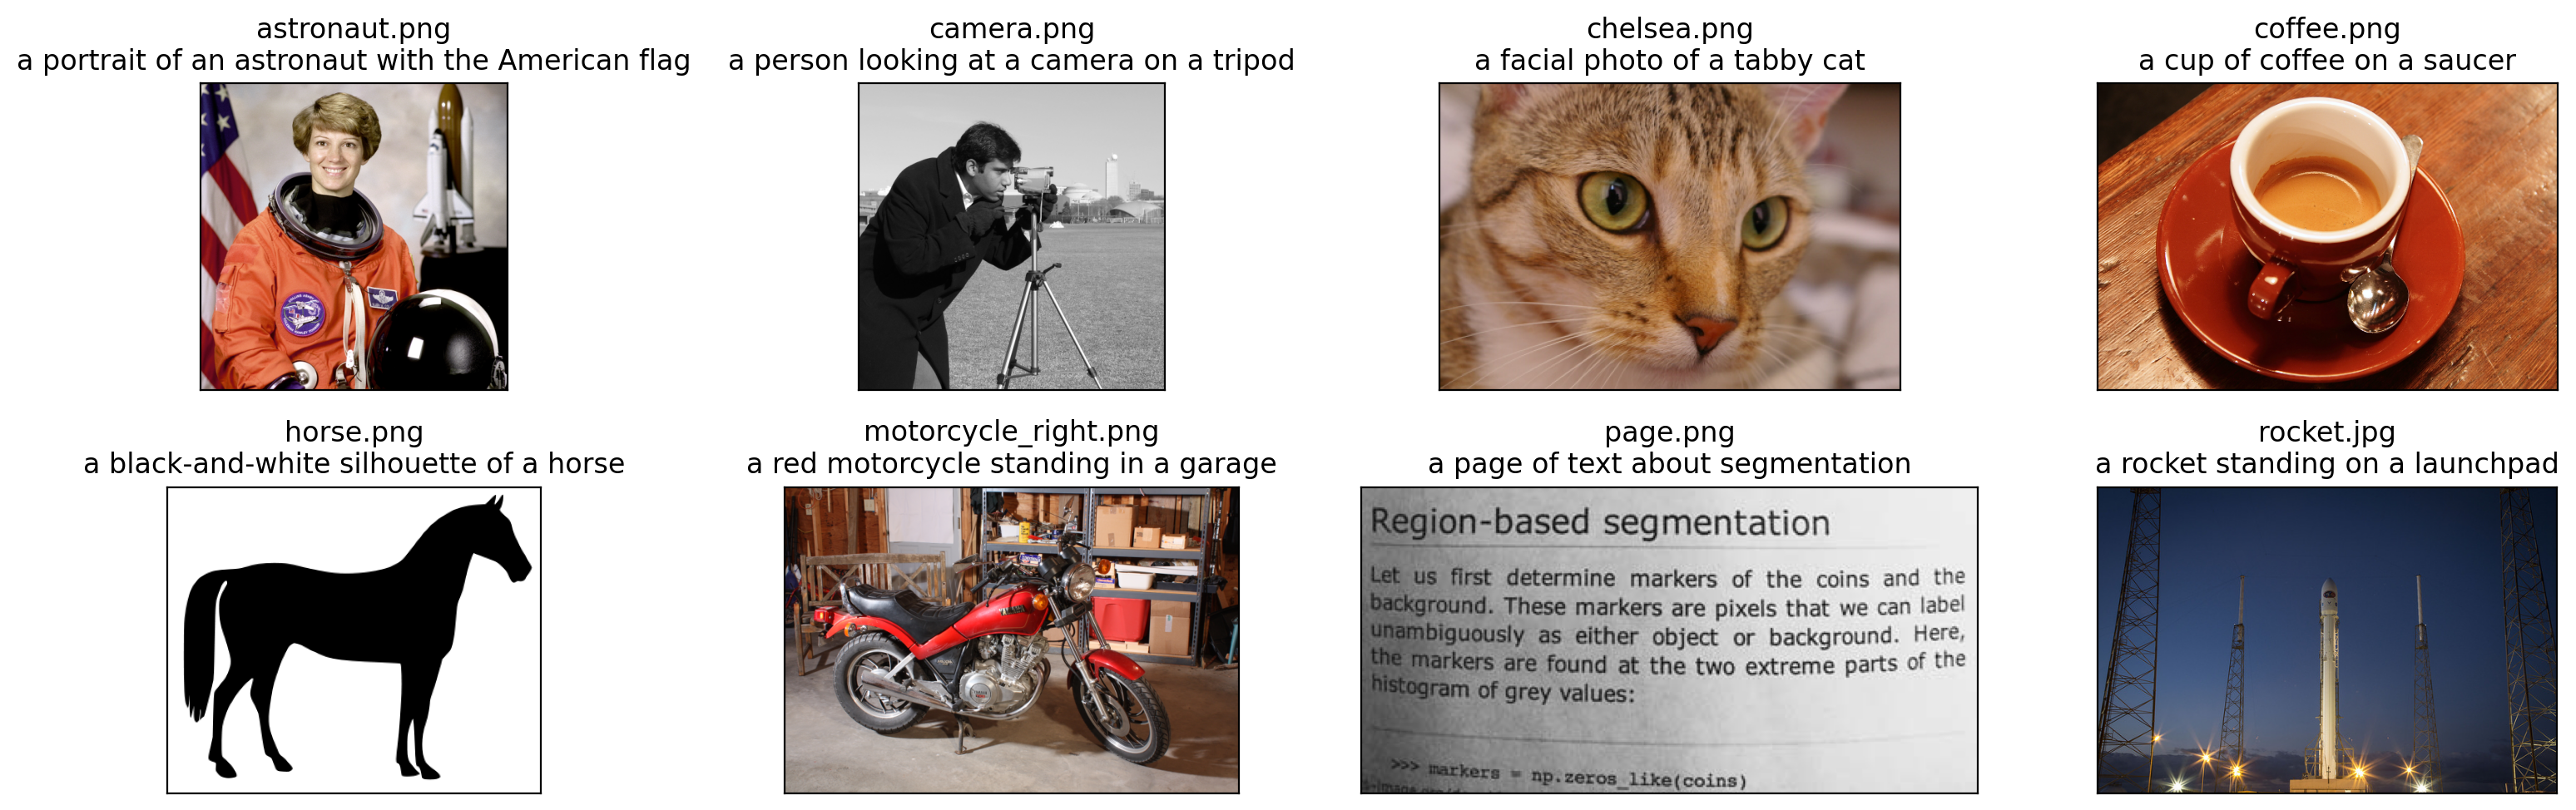

In [68]:
original_images = []
images = []
texts = []
plt.figure(figsize=(16, 5))

for filename in [filename for filename in os.listdir(skimage.data_dir) if filename.endswith(".png") or filename.endswith(".jpg")]:
    name = os.path.splitext(filename)[0]
    if name not in descriptions:
        continue

    image = Image.open(os.path.join(skimage.data_dir, filename)).convert("RGB")

    plt.subplot(2, 4, len(images) + 1)
    plt.imshow(image)
    plt.title(f"{filename}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)
    images.append(processor(image))
    texts.append(descriptions[name])

plt.tight_layout()


## Building features

We normalize the images, tokenize each text input, and run the forward pass of the model to get the image and text features.

In [69]:
image_input = torch.stack(images).to(device)
text_tokens = clip.tokenize(["This is " + desc for desc in texts]).to(device)

TypeError: expected Tensor as element 0 in argument 0, but got BatchFeature

In [71]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

AttributeError: 'CLIPModel' object has no attribute 'encode_image'

## Calculating cosine similarity

We normalize the features and calculate the dot product of each pair.

In [72]:
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
#similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T

print(image_features.shape)
print(text_features.shape)

similarity = image_features @ text_features.T

AttributeError: 

In [73]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity.cpu().numpy(), vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

NameError: name 'similarity' is not defined

<Figure size 2000x1400 with 0 Axes>

#### Zero-Shot Image Classification

You can classify images using the cosine similarity (times 100) as the logits to the softmax operation.

In [74]:
from torchvision.datasets import CIFAR10

cifar10 = CIFAR10(os.path.expanduser("~/.cache"), transform=processor, download=True)

In [58]:
text_descriptions = [f"This is a photo of a {label}" for label in cifar10.classes]
text_tokens = processor.tokenizer(text_descriptions).to(device)

skimage.im

NameError: name 'cifar10' is not defined

In [57]:
with torch.no_grad():
    image_features = model.get_image_features(image_input).float()
    text_features = model.encode_text(text_tokens).float()

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)


text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

AttributeError: 'list' object has no attribute 'shape'

NameError: name 'top_probs' is not defined

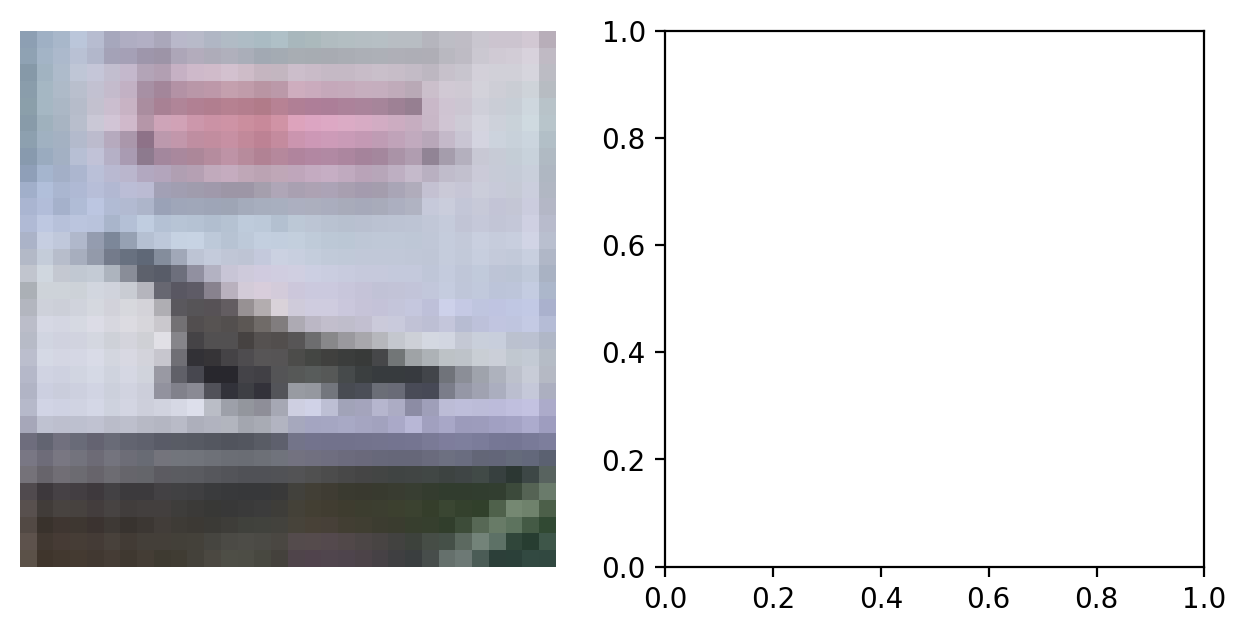

In [104]:
plt.figure(figsize=(16, 16))

for i, image in enumerate(original_images):
    plt.subplot(4, 4, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(4, 4, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()

PCA is a way to simplify complex data by reducing many features into a few important ones.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reuse the normalized image_features already computed above
image_embeddings = image_features.cpu().numpy()  # shape: [N, 512]

# --- Step 1: K-Means Clustering ---
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(image_embeddings)

print("Cluster assignments:")
for name, label in zip(texts, cluster_labels):
    print(f"  Cluster {label}: {name}")

# --- Step 2: Display images grouped by cluster ---
for cluster_id in range(N_CLUSTERS):
    cluster_imgs = [(original_images[i], texts[i])
                    for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_id]
    n = len(cluster_imgs)
    if n == 0:
        continue
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Cluster {cluster_id}', fontsize=14, fontweight='bold')
    for ax, (img, label) in zip(axes, cluster_imgs):
        ax.imshow(img)
        ax.set_title(label, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Step 3: PCA 2D visualization ---
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(image_embeddings)
colors = plt.cm.tab10.colors

plt.figure(figsize=(8, 6))
for i, (x, y) in enumerate(embeddings_2d):
    c = colors[cluster_labels[i]]
    plt.scatter(x, y, color=c, s=120, zorder=2)
    plt.annotate(texts[i], (x, y), textcoords='offset points', xytext=(8, 4), fontsize=9)

for cluster_id in range(N_CLUSTERS):
    plt.scatter([], [], color=colors[cluster_id], label=f'Cluster {cluster_id}', s=80)

plt.legend(fontsize=10)
plt.title('CLIP Image Embeddings — K-Means Clustering (PCA 2D)', fontsize=13)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# CLIP ViT-B/32 image embeddings are 512-dimensional.
print("Embedding dimension:", model.config.projection_dim)


# Step 4 - Load Images from Folder Structure
# Expected layout:
# dataset/
#   dog/
#   cat/
#   car/
#   bird/
dataset_dir = "./images"


images = []
image_paths = []
labels = []

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

for folder in os.listdir(os.path.expanduser(dataset_dir)):
    folder_path = os.path.join(dataset_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)
        if not os.path.isfile(path):
            continue
        if os.path.splitext(file)[1].lower() not in valid_ext:
            continue

        images.append(Image.open(path).convert("RGB"))
        image_paths.append(path)
        labels.append(folder)

print(f"Loaded {len(images)} images from {len(set(labels))} classes")


# Step 5 - Generate Image Embeddings
embeddings = []

with torch.no_grad():
    for img in images:
        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model.get_image_features(**inputs)
     #   embeddings.append(outputs.detach().cpu().numpy()[0])

image_embeddings = np.array(embeddings)
print("image_embeddings shape:", image_embeddings.shape)

# Each image now has a semantic feature vector in image_embeddings.

# Project

## functions

In [26]:
def load_openai_clip(device: str) -> tuple[Any, Any]:
	"""Load OpenAI CLIP with model name ViT-B/32."""
	try:
		import clip
	except ModuleNotFoundError as exc:
		raise ModuleNotFoundError(
			"OpenAI CLIP is not installed. Run: pip install git+https://github.com/openai/CLIP.git"
		) from exc

	openai_model, openai_preprocess = clip.load("ViT-B/32", device=device)
	openai_model.eval()
	return openai_model, openai_preprocess


def load_clip(device: str) -> tuple[CLIPModel, CLIPProcessor]:
	"""Step 3: Load Hugging Face CLIP model and processor."""
	model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
	model.eval()
	processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
	return model, processor

In [27]:
import typing as Any

def cluster_embeddings(x: np.ndarray, n_clusters: int = 5) -> np.ndarray:
	"""Step 6: Cluster embeddings with K-Means."""
	kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
	return kmeans.fit_predict(x)


def reduce_for_plot(x: np.ndarray, method: str = "tsne") -> np.ndarray:
	"""Step 7: Reduce embedding dimensions to 2D for visualization."""
	if method.lower() == "pca":
		reducer = PCA(n_components=2, random_state=42)
		return reducer.fit_transform(x)

	# t-SNE works better with moderate perplexity for small datasets.
	perplexity = min(30, max(5, len(x) // 10))
	reducer = TSNE(n_components=2, random_state=42, init="pca", perplexity=perplexity)
	return reducer.fit_transform(x)


In [28]:
def plot_clusters(x_2d: np.ndarray, labels: np.ndarray, title: str) -> None:
	"""Create a scatter plot for semantic clusters."""
	plt.figure(figsize=(10, 7))
	unique_labels = np.unique(labels)
	colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

	for i, cid in enumerate(unique_labels):
		mask = labels == cid
		plt.scatter(x_2d[mask, 0], x_2d[mask, 1], s=60, color=colors[i], label=f"Cluster {int(cid)}")

	plt.title(title)
	plt.xlabel("Component 1")
	plt.ylabel("Component 2")
	plt.legend(loc="best")
	plt.tight_layout()
	plt.show()

In [29]:
def analyze_clusters(cluster_labels: np.ndarray, true_labels: list[str]) -> dict[int, dict[str, Any]]:
	"""Step 8: Summarize class composition inside each cluster."""
	summary: dict[int, dict[str, Any]] = {}
	grouped: dict[int, list[str]] = defaultdict(list)

	for pred, truth in zip(cluster_labels, true_labels):
		grouped[int(pred)].append(truth)

	for cid, classes in grouped.items():
		counts = Counter(classes)
		top_class, top_count = counts.most_common(1)[0]
		purity = top_count / len(classes)
		summary[cid] = {
			"size": len(classes),
			"top_class": top_class,
			"purity": purity,
			"distribution": dict(counts),
		}

	return summary

In [30]:
def write_report(
	report_path: Path,
	dataset_dir: Path,
	num_images: int,
	embedding_dim: int,
	n_clusters: int,
	silhouette: float,
	cluster_summary: dict[int, dict[str, Any]],
) -> None:
	"""Step 10: Save a concise result summary."""
	lines = [
		"Semantic Image Clustering with CLIP",
		"",
		"1. Dataset description",
		f"- Source folder: {dataset_dir}",
		f"- Number of images: {num_images}",
		"",
		"2. CLIP model explanation",
		"- Model: openai/clip-vit-base-patch32",
		f"- Embedding dimension: {embedding_dim}",
		"",
		"3. Embedding generation",
		"- One embedding vector generated per image using CLIP image encoder.",
		"",
		"4. Clustering method",
		f"- K-Means with n_clusters={n_clusters}",
		"",
		"5. Visualization",
		"- 2D projection using t-SNE/PCA and colored by cluster.",
		"",
		"6. Results and discussion",
		f"- Silhouette Score: {silhouette:.4f}",
	]

	for cid in sorted(cluster_summary):
		item = cluster_summary[cid]
		lines.append(
			f"- Cluster {cid}: size={item['size']}, top_class={item['top_class']}, purity={item['purity']:.2f}"
		)

	report_path.write_text("\n".join(lines), encoding="utf-8")


In [31]:
def load_images_from_folder(root_dir: Path, max_images: int = 500) -> tuple[list[Image.Image], list[str], list[str]]:
	"""Step 4: Load images from class subfolders."""
	valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
	images: list[Image.Image] = []
	image_paths: list[str] = []
	class_names: list[str] = []

	for class_dir in sorted(root_dir.iterdir()):
		if not class_dir.is_dir():
			continue

		for img_path in sorted(class_dir.iterdir()):
			if len(images) >= max_images:
				return images, image_paths, class_names

			if img_path.suffix.lower() not in valid_ext:
				continue

			with Image.open(img_path) as img:
				images.append(img.convert("RGB"))
			image_paths.append(str(img_path))
			class_names.append(class_dir.name)

	return images, image_paths, class_names


In [32]:
def create_embeddings(
	images: list[Image.Image],
	model: CLIPModel,
	processor: CLIPProcessor,
	device: str,
) -> np.ndarray:
	"""Step 5: Convert each image into a semantic embedding vector."""
	embeddings: list[np.ndarray] = []

	with torch.no_grad():
		for img in images:
			inputs = processor(images=img, return_tensors="pt")
			inputs = {k: v.to(device) for k, v in inputs.items()}
			raw_outputs = model.get_image_features(**inputs)

			# Depending on transformers version/model wrapper, this may be a Tensor
			# or a model output object (e.g., BaseModelOutputWithPooling).
			if isinstance(raw_outputs, torch.Tensor):
				features = raw_outputs
			elif hasattr(raw_outputs, "image_embeds"):
				features = raw_outputs.image_embeds
			elif hasattr(raw_outputs, "pooler_output"):
				features = raw_outputs.pooler_output
			elif isinstance(raw_outputs, (tuple, list)) and len(raw_outputs) > 0:
				features = raw_outputs[0]
			else:
				raise TypeError(f"Unsupported CLIP output type: {type(raw_outputs)}")

            
			embeddings.append(features.detach().cpu().numpy()[0])

	if not embeddings:
		return np.empty((0, model.config.projection_dim), dtype=np.float32)
	print(type(features))
	print(features.shape)
	return np.array(embeddings, dtype=np.float32)



def cluster_embeddings(x: np.ndarray, n_clusters: int = 5) -> np.ndarray:
	"""Step 6: Cluster embeddings with K-Means."""
	kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
	return kmeans.fit_predict(x)


## Modified functions

In [33]:
@torch.compile
def load_clip():
    """ Uses cuda if available, else falls back to cpu"""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    """Load Hugging Face CLIP model and processor."""
    model = CLIPModel.from_pretrained(
        "openai/clip-vit-base-patch32"
        #torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
    ).to(device)
    model.eval()
    
    processor = CLIPProcessor.from_pretrained(
        "openai/clip-vit-base-patch32"
        #torch_dtype=torch.bfloat16 if torch.cuda.is_available() else void
    )
    model = torch.compile(model, mode="max-autotune", fullgraph=True)

    return model, processor

In [34]:
import gc
def create_embeddings(images, batch_size, model, processor, device):

    output = np.empty(shape=(0,512), dtype=float)

    result_arrays = np.array_split(images, len(images) // batch_size)
    
    for batch in result_arrays:
            with torch.inference_mode():
                inputs = processor(images=batch, return_tensors="pt")
                pixel_values = inputs["pixel_values"].to(device)

                features = model.get_image_features(pixel_values).pooler_output

                embeddings = features.detach().cpu().float().numpy()
                output = np.concatenate((output, embeddings), axis=0)
                del batch
                gc.collect()
                torch.cuda.empty_cache()
        
    return np.array(output, dtype=np.float32)

## Inference

Using device: cuda
Loaded OpenAI CLIP model: ViT-B/32


Loading weights: 100%|████████████████████████████████████████████████████████████| 398/398 [00:00<00:00, 16583.05it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIP embedding dimension: 512
Loaded 500 images from 1 classes.
Example image: images\airplane\0000.jpg
<class 'torch.Tensor'>
torch.Size([1, 512])
Embeddings shape: (500, 512)
Assigned clusters for 500 images.


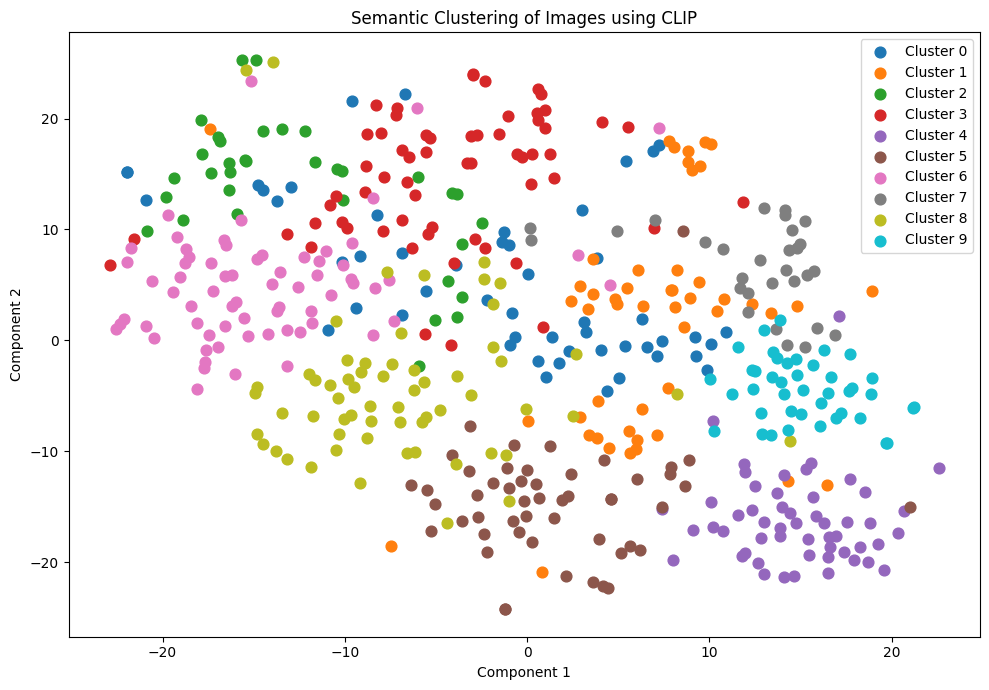


Cluster analysis:
Cluster 0: size=51, top_class=airplane, purity=1.00
Cluster 1: size=49, top_class=airplane, purity=1.00
Cluster 2: size=34, top_class=airplane, purity=1.00
Cluster 3: size=61, top_class=airplane, purity=1.00
Cluster 4: size=53, top_class=airplane, purity=1.00
Cluster 5: size=51, top_class=airplane, purity=1.00
Cluster 6: size=68, top_class=airplane, purity=1.00
Cluster 7: size=29, top_class=airplane, purity=1.00
Cluster 8: size=62, top_class=airplane, purity=1.00
Cluster 9: size=42, top_class=airplane, purity=1.00

Silhouette Score: 0.0514
Saved report to: clustering_report.txt
Runtime: 20.073231799993664 seconds
0.04014646359998733 seconds per image


In [12]:
start = time.perf_counter()

torch._dynamo.config.verbose = True
torch._dynamo.config.suppress_errors = False


dataset_dir = Path("images") if Path("images").is_dir() else Path("images")
if not dataset_dir.is_dir():
	raise FileNotFoundError("Expected a 'dataset/' or 'images/' folder in the current directory.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Explicitly load OpenAI CLIP with ViT-B/32 as requested.
openai_model, openai_preprocess = load_openai_clip(device)
print("Loaded OpenAI CLIP model: ViT-B/32")

model, processor = load_clip(device)
embedding_dim = int(model.config.projection_dim)
print(f"CLIP embedding dimension: {embedding_dim}")

images, image_paths, true_labels = load_images_from_folder(dataset_dir, max_images=500)
if len(images) < 2:
	raise ValueError("Need at least 2 images to run clustering.")

print(f"Loaded {len(images)} images from {len(set(true_labels))} classes.")
if image_paths:
	print(f"Example image: {image_paths[0]}")



x = create_embeddings(images, model, processor, device)
print("Embeddings shape:", x.shape)



n_clusters = min(5, len(images))
cluster_labels = cluster_embeddings(x, n_clusters=10)
print(f"Assigned clusters for {len(cluster_labels)} images.")

x_2d = reduce_for_plot(x, method="tsne")
plot_clusters(x_2d, cluster_labels, "Semantic Clustering of Images using CLIP")

# Step 8 - Analyze clusters
summary = analyze_clusters(cluster_labels, true_labels)
print("\nCluster analysis:")
for cid in sorted(summary):
	item = summary[cid]
	print(
		f"Cluster {cid}: size={item['size']}, top_class={item['top_class']}, purity={item['purity']:.2f}"
	)

# Step 9 - Evaluate quality
silhouette = silhouette_score(x, cluster_labels) if len(np.unique(cluster_labels)) > 1 else -1.0
print(f"\nSilhouette Score: {silhouette:.4f}")

# Step 10 - Present results
report_path = Path("clustering_report.txt")
write_report(
	report_path=report_path,
	dataset_dir=dataset_dir,
	num_images=len(images),
	embedding_dim=embedding_dim,
	n_clusters=n_clusters,
	silhouette=silhouette,
	cluster_summary=summary,
)
print(f"Saved report to: {report_path}")

result = sum(i*i for i in range(10_000_000))

end = time.perf_counter()

print("Runtime:", end - start, "seconds")


print(f"{(end - start) / len(images)} seconds per image")


## experimental inference

Using device: cuda
CLIP embedding dimension: 512
Loaded 10000 images from 10 classes.
Example image: images\airplane\0000.jpg
Embeddings shape: (10000, 512)
Assigned clusters for 10000 images.


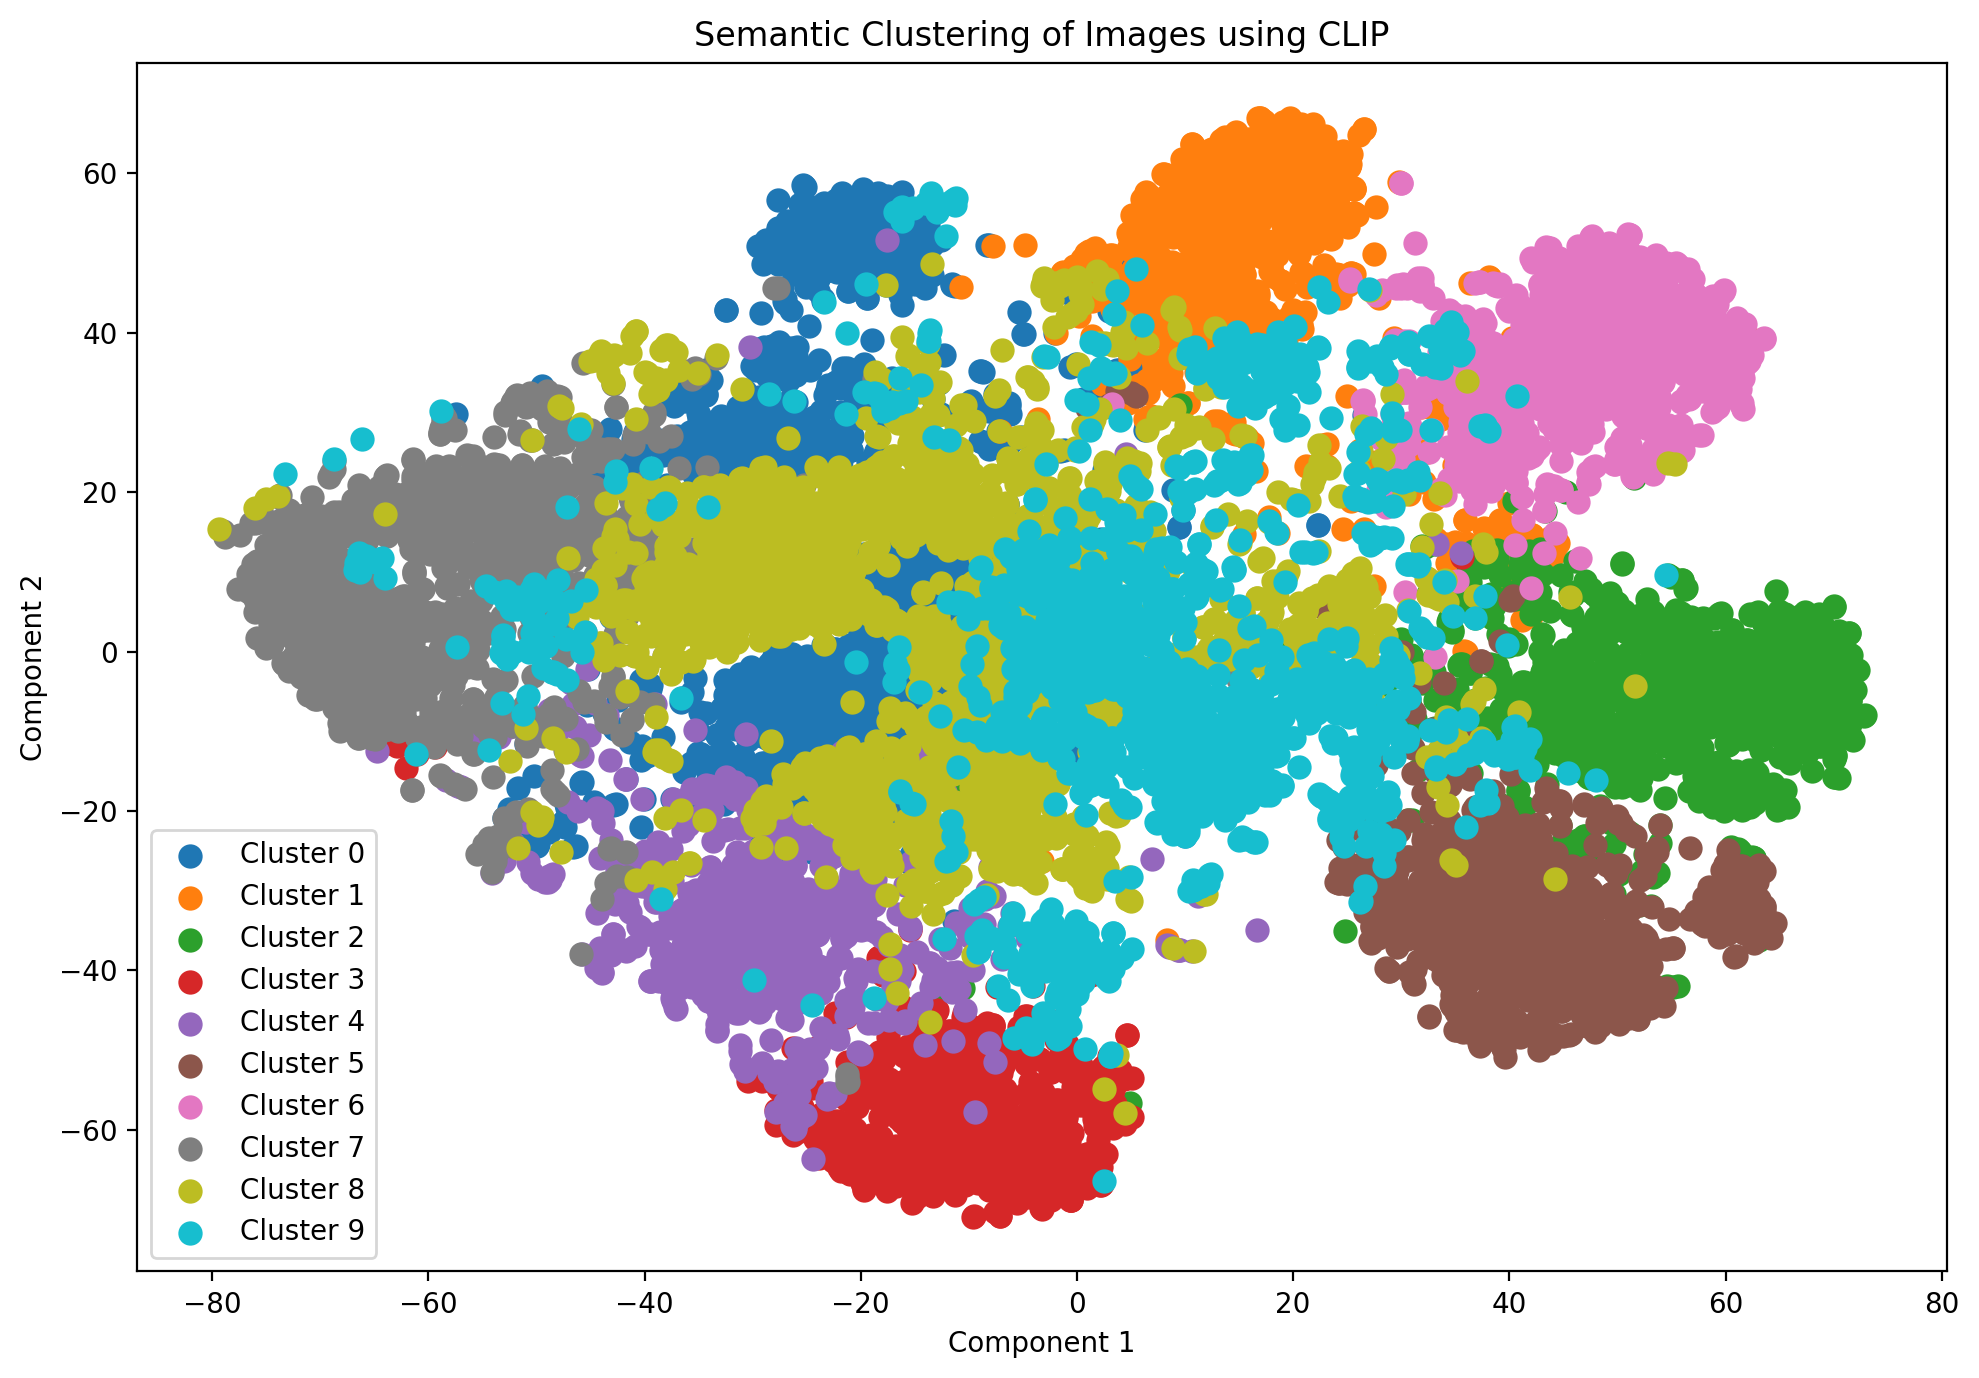


Cluster analysis:
Cluster 0: size=1163, top_class=frog, purity=0.44
Cluster 1: size=731, top_class=airplane, purity=0.90
Cluster 2: size=953, top_class=truck, purity=0.87
Cluster 3: size=688, top_class=horse, purity=0.96
Cluster 4: size=652, top_class=deer, purity=0.67
Cluster 5: size=871, top_class=automobile, purity=0.95
Cluster 6: size=860, top_class=ship, purity=0.94
Cluster 7: size=1122, top_class=dog, purity=0.52
Cluster 8: size=1674, top_class=cat, purity=0.21
Cluster 9: size=1286, top_class=frog, purity=0.16

Silhouette Score: 0.0832
Saved report to: clustering_report.txt
Runtime: 72.62700459999905 seconds
0.007262700459999906 seconds per image


In [36]:
start = time.perf_counter()


torch._dynamo.config.verbose = True
torch._dynamo.config.suppress_errors = False




dataset_dir = Path("images") if Path("images").is_dir() else Path("images")
if not dataset_dir.is_dir():
	raise FileNotFoundError("Expected a 'dataset/' or 'images/' folder in the current directory.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


embedding_dim = int(model.config.projection_dim)
print(f"CLIP embedding dimension: {embedding_dim}")

images, image_paths, true_labels = load_images_from_folder(dataset_dir, max_images=10000)
if len(images) < 2:
	raise ValueError("Need at least 2 images to run clustering.")

print(f"Loaded {len(images)} images from {len(set(true_labels))} classes.")
if image_paths:
	print(f"Example image: {image_paths[0]}")


x = create_embeddings(images, 500, model, processor, device)
print("Embeddings shape:", x.shape)
#print(f"Time for creating embeddings {(end - start)} seconds")



n_clusters = min(5, len(images))
cluster_labels = cluster_embeddings(x, n_clusters=10)
print(f"Assigned clusters for {len(cluster_labels)} images.")

x_2d = reduce_for_plot(x, method="tsne")
plot_clusters(x_2d, cluster_labels, "Semantic Clustering of Images using CLIP")

# Step 8 - Analyze clusters
summary = analyze_clusters(cluster_labels, true_labels)
print("\nCluster analysis:")
for cid in sorted(summary):
	item = summary[cid]
	print(
		f"Cluster {cid}: size={item['size']}, top_class={item['top_class']}, purity={item['purity']:.2f}"
	)

# Step 9 - Evaluate quality
silhouette = silhouette_score(x, cluster_labels) if len(np.unique(cluster_labels)) > 1 else -1.0
print(f"\nSilhouette Score: {silhouette:.4f}")

# Step 10 - Present results
report_path = Path("clustering_report.txt")
write_report(
	report_path=report_path,
	dataset_dir=dataset_dir,
	num_images=len(images),
	embedding_dim=embedding_dim,
	n_clusters=n_clusters,
	silhouette=silhouette,
	cluster_summary=summary,
)
print(f"Saved report to: {report_path}")

result = sum(i*i for i in range(10_000_000))

end = time.perf_counter()

print("Runtime:", end - start, "seconds")


print(f"{(end - start) / len(images)} seconds per image")


# Creating embeddings from text

In [116]:
from torch import nn
images, image_paths, true_labels = load_images_from_folder(dataset_dir, max_images=500)

print(f"Loaded {len(images)} images from {len(set(true_labels))} classes.")
if image_paths:
	print(f"Example image: {image_paths[0]}")

token = processor.tokenizer(text="A image of an that is Airplane").to("cuda")

print(type(token))

Loaded 500 images from 1 classes.
Example image: images\airplane\0000.jpg
<class 'transformers.tokenization_utils_base.BatchEncoding'>
